# Your First Data Science Project
## What can real online store data tell us?
**Coding Mermaid • Guided Python EDA • Beginner level**

Explore real transactions from a UK gift retailer. You will inspect a dataset, document cleaning decisions, answer five questions with charts, and write a short findings report.

**Prerequisites:** basic Python variables, comparisons, and functions. Pandas operations are explained as we use them. Allow roughly 2–3 hours at your own pace. No GPU is needed.

### How to use this notebook in Colab
Upload this `.ipynb` notebook to Google Colab. Run cells in order using the play button beside each code cell (or Shift+Enter). Read the explanation, predict the result, then run the code. The first data load can take a minute. The outputs below were generated during local validation; rerunning replaces them.

### Our scope
One row is an invoice **line**, not necessarily an entire order. We will distinguish units, invoice lines, invoices, and monetary value. This is an educational analysis of one historical retailer, not a description of all online shoppers.

## 1. Source and project brief
**Source:** Daqing Chen (2015), *Online Retail*, UCI Machine Learning Repository. DOI: https://doi.org/10.24432/C5BW33

Dataset page: https://archive.ics.uci.edu/dataset/352/online+retail  
License: CC BY 4.0 — https://creativecommons.org/licenses/by/4.0/

The source describes 541,909 records from **1 December 2010 through 9 December 2011**, from a UK online retailer selling gifts. Many customers are wholesalers. Unit prices are in pounds sterling (GBP). An invoice beginning with C indicates a cancellation.

**Our brief:** describe recorded purchasing activity and identify questions a store manager might investigate next. We will not claim that a chart proves a cause or that sales value equals profit.

| Column | Meaning |
|---|---|
| InvoiceNo | Invoice identifier; C prefix indicates cancellation |
| StockCode | Product code; also inspect non-product codes |
| Description | Product description |
| Quantity | Units on the invoice line |
| InvoiceDate | Invoice timestamp |
| UnitPrice | Price per unit in GBP |
| CustomerID | Customer identifier, when recorded |
| Country | Customer country |

In [1]:
from pathlib import Path
from urllib.request import urlopen
from zipfile import ZipFile
from io import BytesIO
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter

plt.rcParams.update({
    "figure.figsize": (10, 5), "figure.dpi": 120,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.titleweight": "bold", "axes.titlesize": 14,
    "axes.prop_cycle": plt.cycler(color=["#8061B5", "#3F858B", "#D29B4B"]),
})
pd.options.display.float_format = "{:,.2f}".format

## 2. Load the original data
We download the archive directly from UCI, then read its Excel file into a **DataFrame**, Pandas' table structure. The local-file check lets you reuse a previously downloaded file. If the download fails, download the dataset from the source page, extract it, upload `Online Retail.xlsx` to Colab, and rerun this cell.

Identifiers are text, even when they contain digits: adding two customer IDs would not make sense.

In [2]:
local_file = Path("Online Retail.xlsx")
if local_file.exists():
    data_file = local_file
else:
    url = "https://archive.ics.uci.edu/static/public/352/online+retail.zip"
    with urlopen(url, timeout=120) as response:
        archive = ZipFile(BytesIO(response.read()))
    data_file = BytesIO(archive.read("Online Retail.xlsx"))

raw = pd.read_excel(data_file, dtype={
    "InvoiceNo": "string", "StockCode": "string", "CustomerID": "string"
})
print(f"Loaded {raw.shape[0]:,} invoice lines and {raw.shape[1]} columns.")
display(raw.head())

Loaded 541,909 invoice lines and 8 columns.


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom


## 3. Inspect before cleaning
`head()` previews rows, `info()` describes types and missingness, and `describe()` summarizes numbers. A count is not a business explanation: investigate unusual values before deciding what to exclude.

**Pause and predict:** should CustomerID be averaged? Does a negative quantity necessarily mean a typo?

In [3]:
raw.info()
display(raw[["Quantity", "UnitPrice"]].describe())
missing = pd.DataFrame({
    "missing_rows": raw.isna().sum(),
    "missing_percent": raw.isna().mean().mul(100).round(2)
})
display(missing)
print("Exact repeated rows:", raw.duplicated().sum())
print("Date range:", raw["InvoiceDate"].min(), "to", raw["InvoiceDate"].max())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  string        
 1   StockCode    541909 non-null  string        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  string        
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(2), string(3)
memory usage: 33.1+ MB
Exact repeated rows: 5268
Date range: 2010-12-01 08:26:00 to 2011-12-09 12:50:00


,Quantity,UnitPrice
count,"541,909.00","541,909.00"
mean,9.55,4.61
std,218.08,96.76
min,"-80,995.00","-11,062.06"
25%,1.00,1.25
50%,3.00,2.08
75%,10.00,4.13
max,"80,995.00","38,970.00"


,missing_rows,missing_percent
InvoiceNo,0,0.00
StockCode,0,0.00
Description,1454,0.27
Quantity,0,0.00
InvoiceDate,0,0.00
UnitPrice,0,0.00
CustomerID,135080,24.93
Country,0,0.00


## 4. Define an analysis policy
We preserve `raw` and work on a copy. These choices define the results, so they belong in the report:

- **Exact repeated rows:** remove them for this tutorial, treating them as repeated records. This is an assumption: without a line ID we cannot prove every exact repeat is accidental. We measure its monetary impact below.
- **Missing CustomerID:** retain those rows for product and country totals. Exclude them only from customer-specific questions; never invent an ID.
- **Cancellations and negative quantities:** preserve them in a separate view. Excluding them produces positive-sales value, not net revenue.
- **Nonpositive prices:** exclude from monetary comparisons. They might represent adjustments or free items; flag rather than silently repair.
- **Product codes:** use codes beginning with five digits as a transparent product-like rule. This removes obvious codes such as POST, DOT, and manual adjustments. It is a heuristic, not a verified merchandise catalogue; inspect the excluded codes.
- **Dates:** compare January–November 2011 for monthly charts. December 2011 ends on the 9th and would be misleading alongside full months.

We define **positive-sales value** as Quantity × UnitPrice for eligible positive, non-cancelled lines. This is not profit or audited revenue and does not subtract cancellations, costs, or tax.

In [4]:
df = raw.copy()
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"], errors="coerce")
repeated = df.duplicated()
print("Repeated rows removed:", int(repeated.sum()))
print("Signed line value on repeated rows (GBP):",
      round((df.loc[repeated, "Quantity"] * df.loc[repeated, "UnitPrice"]).sum(), 2))
df = df.drop_duplicates().copy()
df["is_cancellation"] = df["InvoiceNo"].str.upper().str.startswith("C", na=False)
df["is_product_like"] = df["StockCode"].str.match(r"^\d{5}", na=False)
df["line_value"] = df["Quantity"] * df["UnitPrice"]

display(pd.Series({
    "rows_after_deduplication": len(df),
    "cancellation_lines": int(df["is_cancellation"].sum()),
    "negative_quantity_lines": int(df["Quantity"].lt(0).sum()),
    "nonpositive_price_lines": int(df["UnitPrice"].le(0).sum()),
    "non_product_like_lines": int((~df["is_product_like"]).sum()),
    "invalid_dates": int(df["InvoiceDate"].isna().sum()),
}, name="Count (flags can overlap)"))
display(df.loc[~df["is_product_like"], ["StockCode", "Description"]]
        .drop_duplicates().head(20))

eligible = df["is_product_like"] & df["UnitPrice"].gt(0) & df["InvoiceDate"].notna()
sales = df.loc[eligible & df["Quantity"].gt(0) & ~df["is_cancellation"]].copy()
sales["month"] = sales["InvoiceDate"].dt.to_period("M")
print(f"Retained {len(sales):,} positive-sales lines from {len(df):,} deduplicated lines.")
print(f"Positive-sales value: £{sales['line_value'].sum():,.2f}")

Repeated rows removed: 5268
Signed line value on repeated rows (GBP): 21740.98
Retained 522,504 positive-sales lines from 536,641 deduplicated lines.
Positive-sales value: £10,246,820.87


rows_after_deduplication    536641
cancellation_lines            9251
negative_quantity_lines      10587
nonpositive_price_lines       2512
non_product_like_lines        2989
invalid_dates                    0
Name: Count (flags can overlap), dtype: int64

,StockCode,Description
45,POST,POSTAGE
141,D,Discount
1423,C2,CARRIAGE
1814,DOT,DOTCOM POSTAGE
2239,M,Manual
4406,BANK CHARGES,Bank Charges
14436,S,SAMPLES
14514,AMAZONFEE,AMAZON FEE
21326,DCGS0076,SUNJAR LED NIGHT NIGHT LIGHT
24906,DCGS0003,BOXED GLASS ASHTRAY


## 5. Which products sell the most units?
`groupby()` gathers rows sharing a product code; `sum()` adds their quantities. `nlargest(10)` selects ten leaders. We group by code because descriptions may vary.

Descriptions are display labels only: we use the most frequent non-empty description for each code. Read the ranked table as well as the chart.

,description,units,positive_sales_gbp
StockCode,,,
23843,"PAPER CRAFT , LITTLE BIRDIE",80995,"168,469.60"
23166,MEDIUM CERAMIC TOP STORAGE JAR,78033,"81,700.92"
22197,POPCORN HOLDER,56898,"51,334.47"
84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,54951,"13,814.01"
85099B,JUMBO BAG RED RETROSPOT,48371,"94,159.81"
85123A,WHITE HANGING HEART T-LIGHT HOLDER,37641,"104,462.75"
21212,PACK OF 72 RETROSPOT CAKE CASES,36396,"21,246.45"
84879,ASSORTED COLOUR BIRD ORNAMENT,36362,"58,927.62"
23084,RABBIT NIGHT LIGHT,30739,"66,870.03"


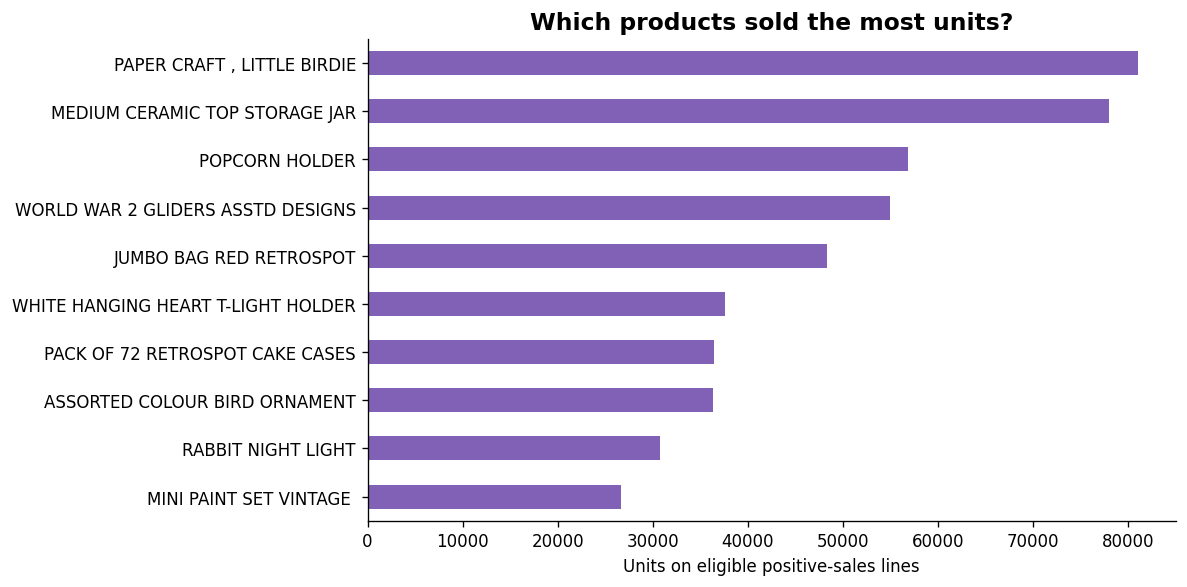

In [5]:
labels = (sales.dropna(subset=["Description"])
          .groupby("StockCode")["Description"]
          .agg(lambda names: names.value_counts().index[0]))
products = sales.groupby("StockCode").agg(
    units=("Quantity", "sum"), positive_sales_gbp=("line_value", "sum")
)
products["description"] = labels
products["description"] = products["description"].fillna("Description unavailable")
top_units = products.nlargest(10, "units")
display(top_units[["description", "units", "positive_sales_gbp"]])
ax = top_units.sort_values("units").set_index("description")["units"].plot.barh()
ax.set(title="Which products sold the most units?", xlabel="Units on eligible positive-sales lines", ylabel="")
plt.tight_layout()
plt.show()

**Try it yourself:** change 10 to 5. Explain why selling the most units does not necessarily mean generating the highest monetary value.

## 6. Which products contribute the most sales value?
Now rank the same products by our defined positive-sales value. Keep the definition consistent. These totals do not account for cancellations or operating costs.

,description,positive_sales_gbp,units
StockCode,,,
22423,REGENCY CAKESTAND 3 TIER,"174,156.54",13851
23843,"PAPER CRAFT , LITTLE BIRDIE","168,469.60",80995
85123A,WHITE HANGING HEART T-LIGHT HOLDER,"104,462.75",37641
47566,PARTY BUNTING,"99,445.23",18283
85099B,JUMBO BAG RED RETROSPOT,"94,159.81",48371
23166,MEDIUM CERAMIC TOP STORAGE JAR,"81,700.92",78033
23084,RABBIT NIGHT LIGHT,"66,870.03",30739
22086,PAPER CHAIN KIT 50'S CHRISTMAS,"64,875.59",19329
84879,ASSORTED COLOUR BIRD ORNAMENT,"58,927.62",36362


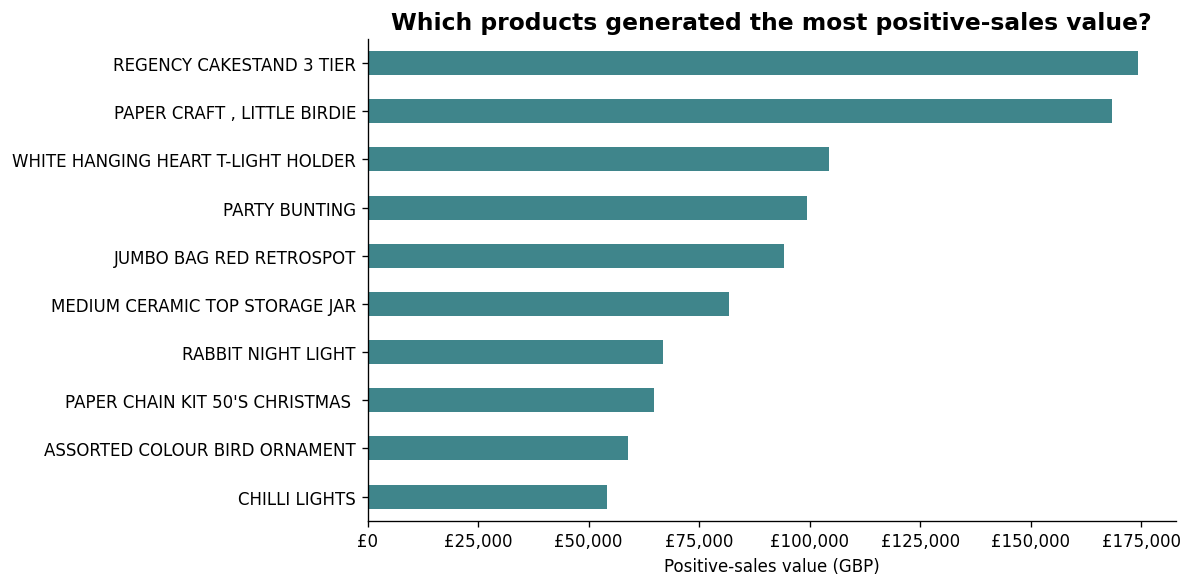

In [6]:
top_value = products.nlargest(10, "positive_sales_gbp")
display(top_value[["description", "positive_sales_gbp", "units"]])
ax = top_value.sort_values("positive_sales_gbp").set_index("description")["positive_sales_gbp"].plot.barh(color="#3F858B")
ax.set(title="Which products generated the most positive-sales value?", xlabel="Positive-sales value (GBP)", ylabel="")
ax.xaxis.set_major_formatter(StrMethodFormatter("£{x:,.0f}"))
plt.tight_layout()
plt.show()

## 7. How does activity change across complete months?
Use a half-open interval: on or after 1 January, before 1 December. This includes all of November regardless of timestamp. `nunique()` counts invoices rather than invoice lines.

A line chart preserves time order. A peak is an observation; this dataset alone cannot establish whether a campaign, holiday, stock availability, or another cause explains it.

,positive_sales_gbp,invoices,units
month,,,
2011-01,"670,361.99",1081,386736
2011-02,"507,783.42",1093,282622
2011-03,"689,708.49",1440,376144
2011-04,"515,354.78",1235,307647
2011-05,"739,914.35",1668,394641
2011-06,"737,558.98",1525,388124
2011-07,"688,144.79",1452,399263
2011-08,"724,196.76",1339,420689
2011-09,"1,028,313.80",1818,568698


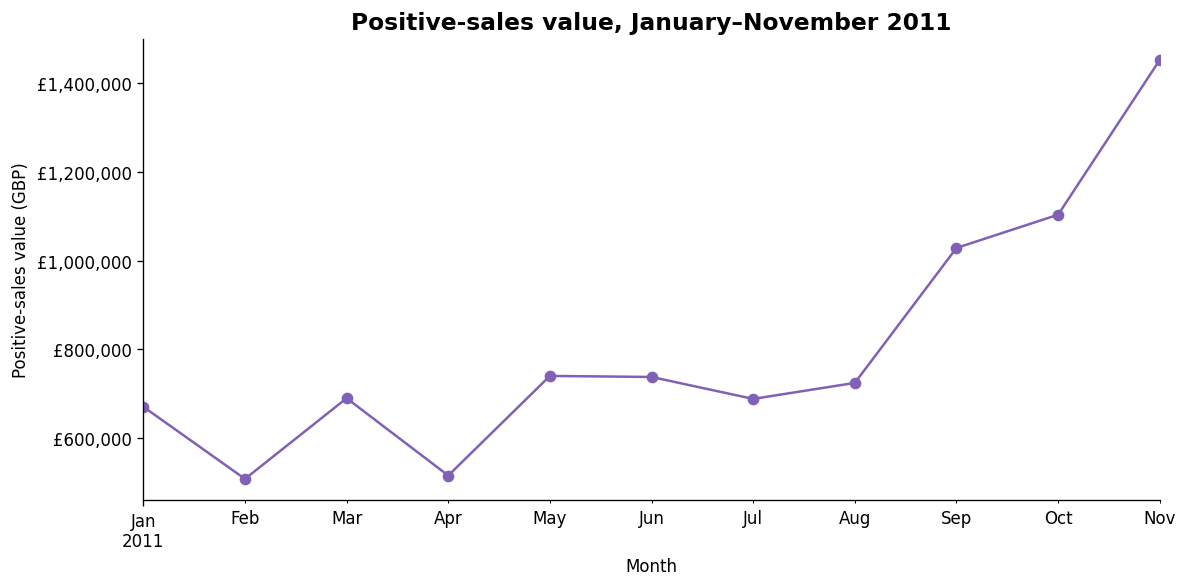

In [7]:
full_month_sales = sales.loc[
    sales["InvoiceDate"].ge("2011-01-01") & sales["InvoiceDate"].lt("2011-12-01")
]
monthly = full_month_sales.groupby("month").agg(
    positive_sales_gbp=("line_value", "sum"),
    invoices=("InvoiceNo", "nunique"), units=("Quantity", "sum")
)
display(monthly)
ax = monthly["positive_sales_gbp"].plot(marker="o")
ax.set(title="Positive-sales value, January–November 2011", xlabel="Month", ylabel="Positive-sales value (GBP)")
ax.yaxis.set_major_formatter(StrMethodFormatter("£{x:,.0f}"))
plt.tight_layout()
plt.show()

## 8. Which countries account for the most sales?
A UK retailer may have a strongly UK-weighted customer base. Show the UK share, then inspect the largest countries outside the UK separately. This is customer country, not proof of delivery destination or wider market demand.

UK share of positive-sales value: 85.1%


Country
United Kingdom   8,724,045.22
Netherlands        283,889.34
EIRE               270,850.86
Germany            205,381.15
France             184,493.00
Australia          138,103.81
Spain               55,706.56
Switzerland         53,065.60
Japan               37,416.37
Belgium             36,927.34
Name: positive_sales_gbp, dtype: float64

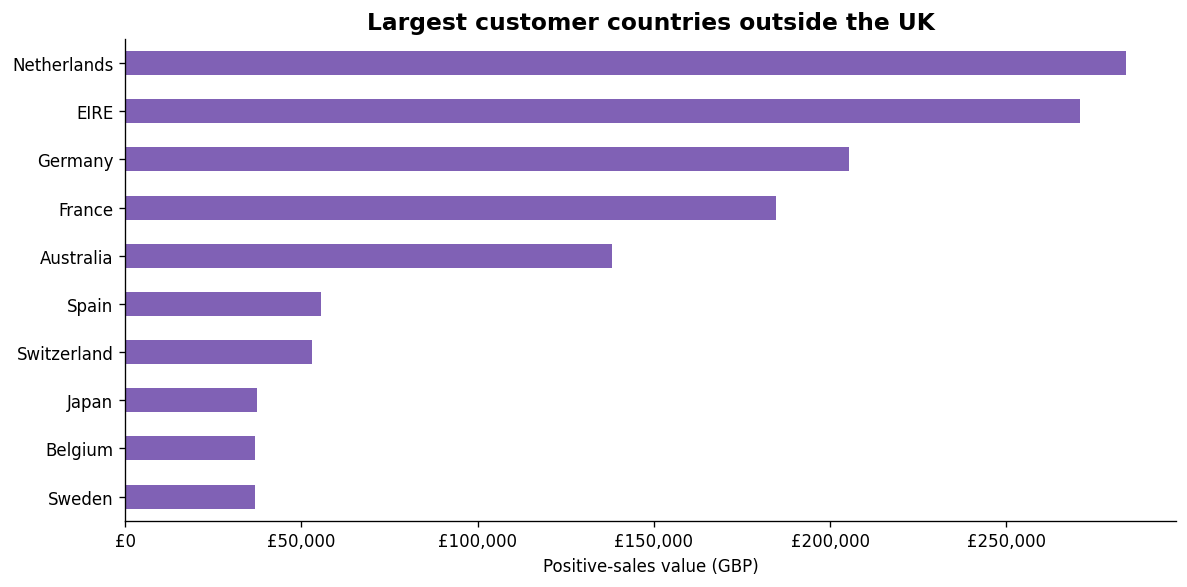

In [8]:
countries = sales.groupby("Country")["line_value"].sum().sort_values(ascending=False)
uk_share = countries.get("United Kingdom", 0) / countries.sum()
print(f"UK share of positive-sales value: {uk_share:.1%}")
display(countries.head(10).rename("positive_sales_gbp"))
ax = countries.drop("United Kingdom", errors="ignore").head(10).sort_values().plot.barh()
ax.set(title="Largest customer countries outside the UK", xlabel="Positive-sales value (GBP)", ylabel="")
ax.xaxis.set_major_formatter(StrMethodFormatter("£{x:,.0f}"))
plt.tight_layout()
plt.show()

## 9. What changes when we include cancellations?
Use the same product-like, positive-price, valid-date scope. Add signed line values, including negative quantities and C-prefixed invoices. Label this **signed recorded value**, not audited net revenue: cancellations may refer to purchases outside our date range, and we have not matched them to original orders.

We also inspect the signs of C-prefixed lines. A C prefix is documented; interpreting every other negative line as a customer return would be an unsupported assumption.

Difference: £475,901.16
C-prefixed lines with nonnegative quantity: 0
Negative lines without a C prefix: 0


Positive-sales value    10,246,820.87
Signed recorded value    9,770,919.71
Name: GBP, dtype: float64

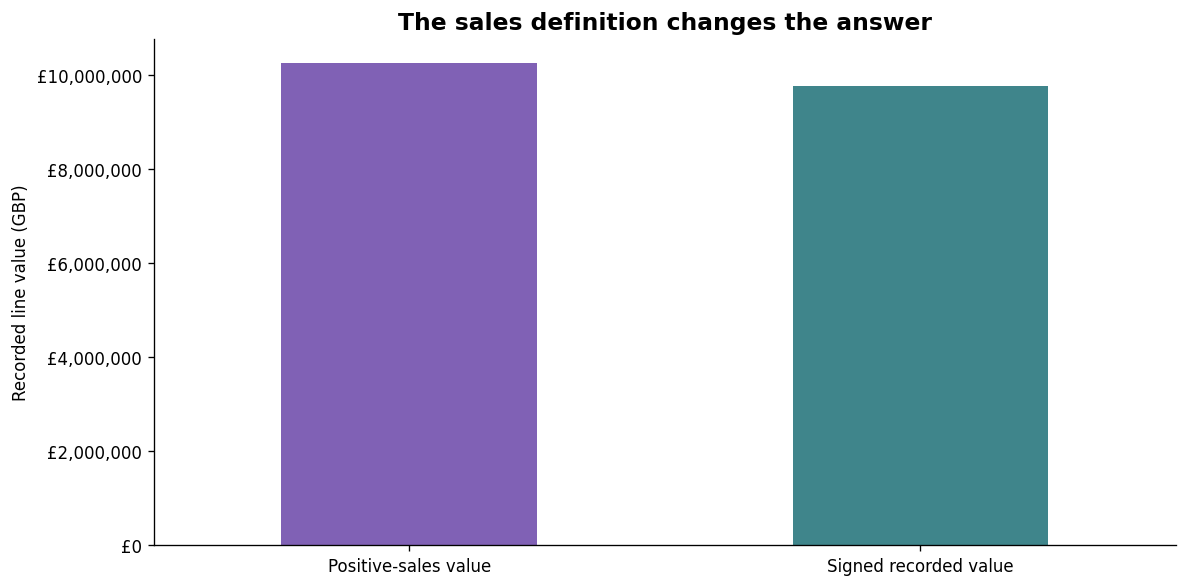

In [9]:
signed = df.loc[eligible].copy()
positive_value = sales["line_value"].sum()
signed_value = signed["line_value"].sum()
comparison = pd.Series({
    "Positive-sales value": positive_value,
    "Signed recorded value": signed_value,
}, name="GBP")
display(comparison)
print(f"Difference: £{positive_value - signed_value:,.2f}")
print("C-prefixed lines with nonnegative quantity:",
      int((signed["is_cancellation"] & signed["Quantity"].ge(0)).sum()))
print("Negative lines without a C prefix:",
      int((~signed["is_cancellation"] & signed["Quantity"].lt(0)).sum()))
ax = comparison.plot.bar(color=["#8061B5", "#3F858B"], rot=0)
ax.set(title="The sales definition changes the answer", ylabel="Recorded line value (GBP)", xlabel="")
ax.yaxis.set_major_formatter(StrMethodFormatter("£{x:,.0f}"))
plt.tight_layout()
plt.show()

## 10. Write findings a reader can verify
Start with a number and scope, then explain an implication and limitation. The next cell creates factual observations from the computed results; it does not invent business explanations.

In [10]:
unit_leader = products["units"].idxmax()
value_leader = products["positive_sales_gbp"].idxmax()
peak_month = monthly["positive_sales_gbp"].idxmax()
print(f"1. Within eligible positive-sales lines, {products.loc[unit_leader, 'description']} ({unit_leader}) led unit sales with {products.loc[unit_leader, 'units']:,.0f} units.")
print(f"2. {products.loc[value_leader, 'description']} ({value_leader}) led positive-sales value at £{products.loc[value_leader, 'positive_sales_gbp']:,.2f}.")
print(f"3. Among January–November 2011, {peak_month} had the highest positive-sales value: £{monthly.loc[peak_month, 'positive_sales_gbp']:,.2f}.")
print(f"4. UK customers accounted for {uk_share:.1%} of positive-sales value across the retained dataset.")
print(f"5. Including signed entries changed the recorded value by £{signed_value - positive_value:,.2f} relative to the positive-sales view.")

1. Within eligible positive-sales lines, PAPER CRAFT , LITTLE BIRDIE (23843) led unit sales with 80,995 units.
2. REGENCY CAKESTAND 3 TIER (22423) led positive-sales value at £174,156.54.
3. Among January–November 2011, 2011-11 had the highest positive-sales value: £1,452,112.69.
4. UK customers accounted for 85.1% of positive-sales value across the retained dataset.
5. Including signed entries changed the recorded value by £-475,901.16 relative to the positive-sales view.


### Your short report
Replace the prompts below with your own words:

**Question:** What did I investigate?  
**Method:** Which rows did I include, and why?  
**Finding:** What number or chart supports my observation?  
**Possible implication:** What might a retailer investigate next?  
**Limitation:** What can this data not establish?

For example, a high unit count may justify reviewing stocking patterns, but it does not establish a profitable product without cost and cancellation information.

### Limitations to carry into your README
- One historical UK gift retailer with wholesale customers is not representative of all e-commerce.
- Customer-specific analysis omits anonymous transactions and can introduce selection bias.
- Deduplication and the product-code heuristic are explicit assumptions; different defensible policies may change rankings.
- Recorded monetary values are not profit. No cost, margin, advertising, or tax model is provided here.
- The final month is incomplete; use comparable time windows.
- Observed associations do not establish causation.

## 11. Independent practice
Before looking at the hints, try these exercises:

1. Compare median and mean invoice value in the positive-sales view. What might explain a gap?
2. Rank countries by unique invoices instead of monetary value. Does the ranking change?
3. Repeat the monthly analysis for UK customers only. Does the peak change?
4. Sensitivity check: retain exact repeats and recalculate positive-sales value using the same rules. Report the absolute and percentage difference.

**Hints:** (1) group by InvoiceNo and sum line_value, then use mean/median; (2) group by Country and call nunique on InvoiceNo; (3) filter full_month_sales before grouping; (4) rebuild flags on raw, rather than using the already-deduplicated df.

## 12. Prepare your GitHub project
Use a repository containing this notebook and a README. Attribute the dataset and link to the original download; the notebook loads the data, so you do not need to commit the Excel file.

Suggested README sections:
1. Project question and dataset attribution
2. How to run the notebook in Colab
3. Definitions and cleaning decisions
4. Three findings supported by charts and numbers
5. Limitations and what you would investigate next

For the article, capture **real Colab screenshots after running**: the first data preview, missing-value table, cleaning summary, product chart, monthly chart, and final findings. Keep code available as text. Do not present locally generated charts as screenshots of Colab.

**Before publishing:** restart the runtime and run all cells in order. Check that outputs are visible, explain your decisions in your own words, and add an independent analysis from the exercises.

### Attribution
Chen, D. (2015). Online Retail [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5BW33. Licensed CC BY 4.0. This notebook filters and summarizes the original dataset as described above. Tutorial: Coding Mermaid.